# Data Exploration & Dataset Selection
I am going to Compare the three available sampling frequencies for the same periodic signal and select one dataset for the subsequent forecasting experiments.

The analysis focuses on data quality, signal structure, periodicity, temporal resolution, and whether the additional resolution provides useful information.

In [9]:
import sys
print(sys.executable)

d:\Mlprojects\signal-forecasting-assignment\.venv\Scripts\python.exe


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATASETS = {
    "30-minute": DATA_DIR / "timeseries_30m.csv",
    "1-hour": DATA_DIR / "timeseries_1h.csv",
    "5-hour": DATA_DIR / "timeseries_5h.csv",
}

SAMPLE_HOURS = {
    "30-minute": 0.5,
    "1-hour": 1.0,
    "5-hour": 5.0,
}

def autocorrelation(values, max_lag):
    values = np.asarray(values, dtype=float)
    values = values - values.mean()
    denominator = np.dot(values, values)

    result = np.empty(max_lag + 1)
    result[0] = 1.0

    for lag in range(1, max_lag + 1):
        result[lag] = np.dot(values[:-lag], values[lag:]) / denominator

    return result

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: D:\Mlprojects\signal-forecasting-assignment
Data directory: D:\Mlprojects\signal-forecasting-assignment\data\raw


## 1. Loading three datasets

In [11]:
data = {}

for name, path in DATASETS.items():
    df = pd.read_csv(path, parse_dates=["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)
    data[name] = df

    print(f"{name}: {df.shape}")
    display(df.head(3))

30-minute: (35088, 2)


,datetime,value
0,2016-01-01 00:00:00,0.022925
1,2016-01-01 00:30:00,0.051618
2,2016-01-01 01:00:00,0.113476


1-hour: (17544, 2)


,datetime,value
0,2016-01-01 00:00:00,-0.101431
1,2016-01-01 01:00:00,0.139217
2,2016-01-01 02:00:00,0.059007


5-hour: (3509, 2)


,datetime,value
0,2016-01-01 00:00:00,0.140965
1,2016-01-01 05:00:00,-0.014609
2,2016-01-01 10:00:00,0.325199


## 2. Data quality and sampling consistency

In [12]:
quality_rows = []

for name, df in data.items():
    intervals = df["datetime"].diff().dropna()
    expected_hours = SAMPLE_HOURS[name]

    quality_rows.append({
        "Dataset": name,
        "Observations": len(df),
        "Start": df["datetime"].min(),
        "End": df["datetime"].max(),
        "Duration (days)": (df["datetime"].max() - df["datetime"].min()).total_seconds() / 86400,
        "Expected interval (h)": expected_hours,
        "Median interval (h)": intervals.dt.total_seconds().median() / 3600,
        "Min interval (h)": intervals.dt.total_seconds().min() / 3600,
        "Max interval (h)": intervals.dt.total_seconds().max() / 3600,
        "Missing values": int(df["value"].isna().sum()),
        "Duplicate timestamps": int(df["datetime"].duplicated().sum()),
    })

quality_summary = pd.DataFrame(quality_rows)
quality_summary

,Dataset,Observations,Start,End,Duration (days),Expected interval (h),Median interval (h),Min interval (h),Max interval (h),Missing values,Duplicate timestamps
0,30-minute,35088,2016-01-01,2017-12-31 23:30:00,730.979167,0.5,0.5,0.5,0.5,0,0
1,1-hour,17544,2016-01-01,2017-12-31 23:00:00,730.958333,1.0,1.0,1.0,1.0,0,0
2,5-hour,3509,2016-01-01,2017-12-31 20:00:00,730.833333,5.0,5.0,5.0,5.0,0,0


Verified sampling period, all datset contain same period

## 3. Signal statistics

In [13]:
stats = []

for name, df in data.items():
    s = df["value"]
    stats.append({
        "Dataset": name,
        "Mean": s.mean(),
        "Std": s.std(),
        "Min": s.min(),
        "Median": s.median(),
        "Max": s.max(),
        "Q25": s.quantile(0.25),
        "Q75": s.quantile(0.75),
    })

pd.DataFrame(stats).set_index("Dataset").round(4)

,Mean,Std,Min,Median,Max,Q25,Q75
Dataset,,,,,,,
30-minute,3.2053,2.1482,-1.1513,2.9404,9.7233,1.5812,4.6662
1-hour,3.2039,2.1482,-1.1811,2.9352,9.7471,1.5796,4.6712
5-hour,3.2026,2.1500,-1.0496,2.9440,9.5846,1.5831,4.6619


## Initial Data Quality and Distribution Assessment

All three datasets cover approximately the same two-year period from 2016 to 2017, but at different sampling frequencies: 30-minute, 1-hour, and 5-hour.

The timestamp analysis shows that all three datasets have regular sampling intervals matching their expected frequencies. There are no missing signal values or duplicate timestamps.

The basic signal statistics are also very similar across the three datasets. The mean is approximately 3.2 and the standard deviation is approximately 2.15 for all three series, with similar quantiles and ranges.

Therefore, data quality and marginal signal distribution do not provide a strong reason to select one dataset over another.

The key question is whether the different sampling frequencies preserve different amounts of useful temporal structure. In particular, we need to investigate the signal's temporal behavior, autocorrelation, and dominant periodicities before selecting the dataset for forecasting.

The dataset selection will therefore be based primarily on the temporal information and predictability contained in each sampling frequency rather than simply choosing the dataset with the largest number of observations.

## 4. Visualise the complete signal

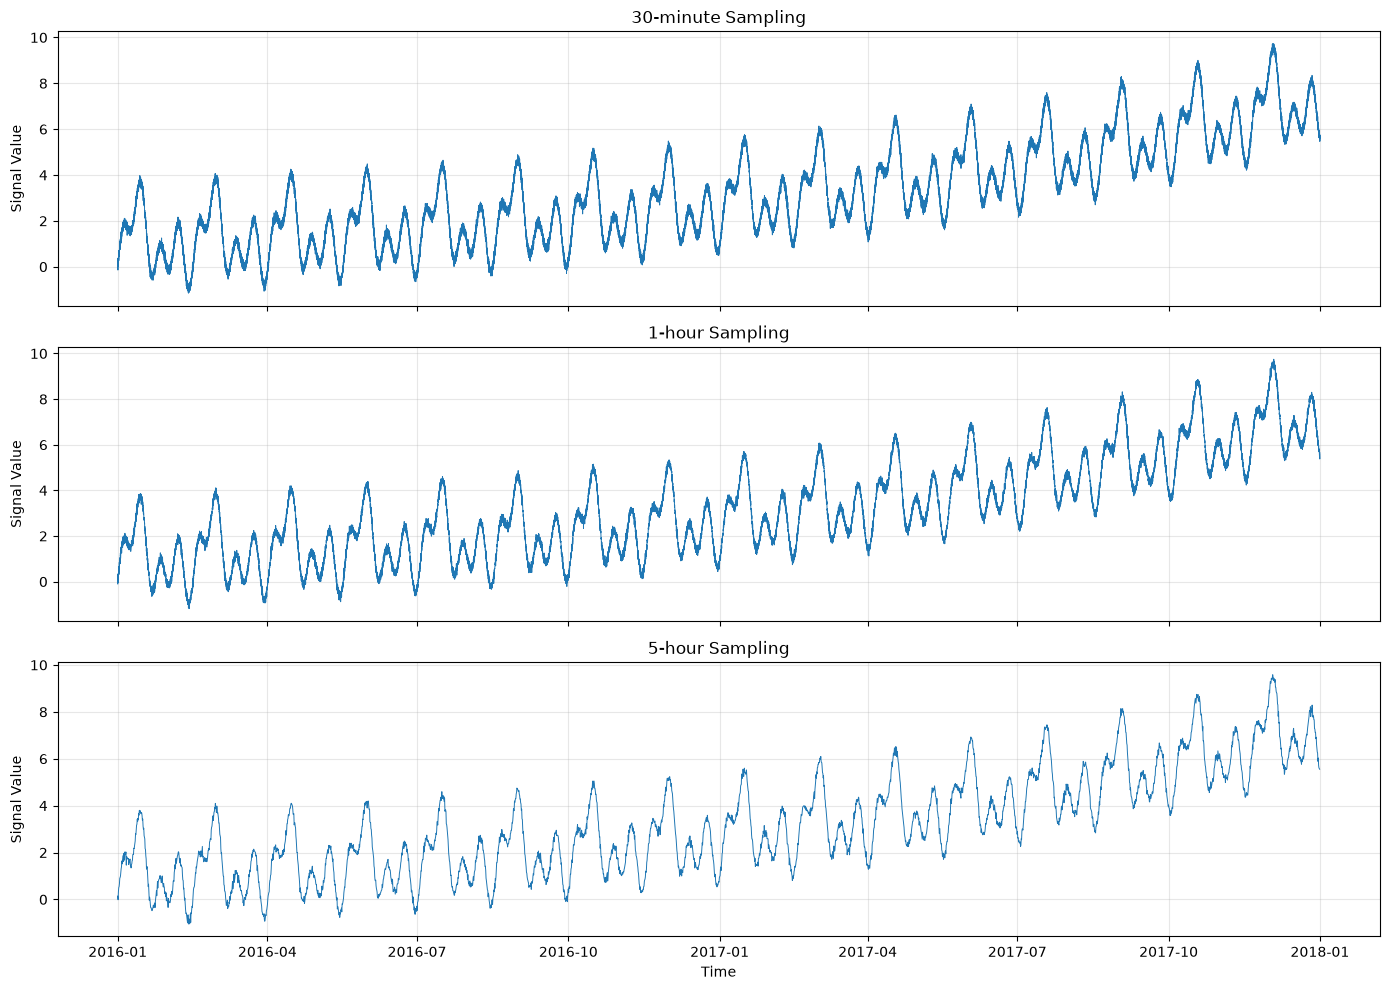

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (name, df) in zip(axes, data.items()):
    ax.plot(df["datetime"], df["value"], linewidth=0.7)
    ax.set_title(f"{name} Sampling")
    ax.set_ylabel("Signal Value")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

## Temporal Behavior of the Signals

The full time-series plots show that all three datasets exhibit similar temporal behavior despite their different sampling frequencies.

A clear upward movement in the signal level is visible over the two-year period, indicating the presence of a slow-varying trend. At the same time, the signal contains repeated oscillations at shorter time scales.

The broad structure of the three series is very similar, suggesting that the different sampling frequencies are capturing the same underlying process. However, the higher-frequency datasets provide more detailed short-term variation.

The plot alone is not sufficient to determine the dominant periodicity. Since the signal contains both a slowly varying component and repeating fluctuations, periodicity will be investigated quantitatively after accounting for the slow variation.

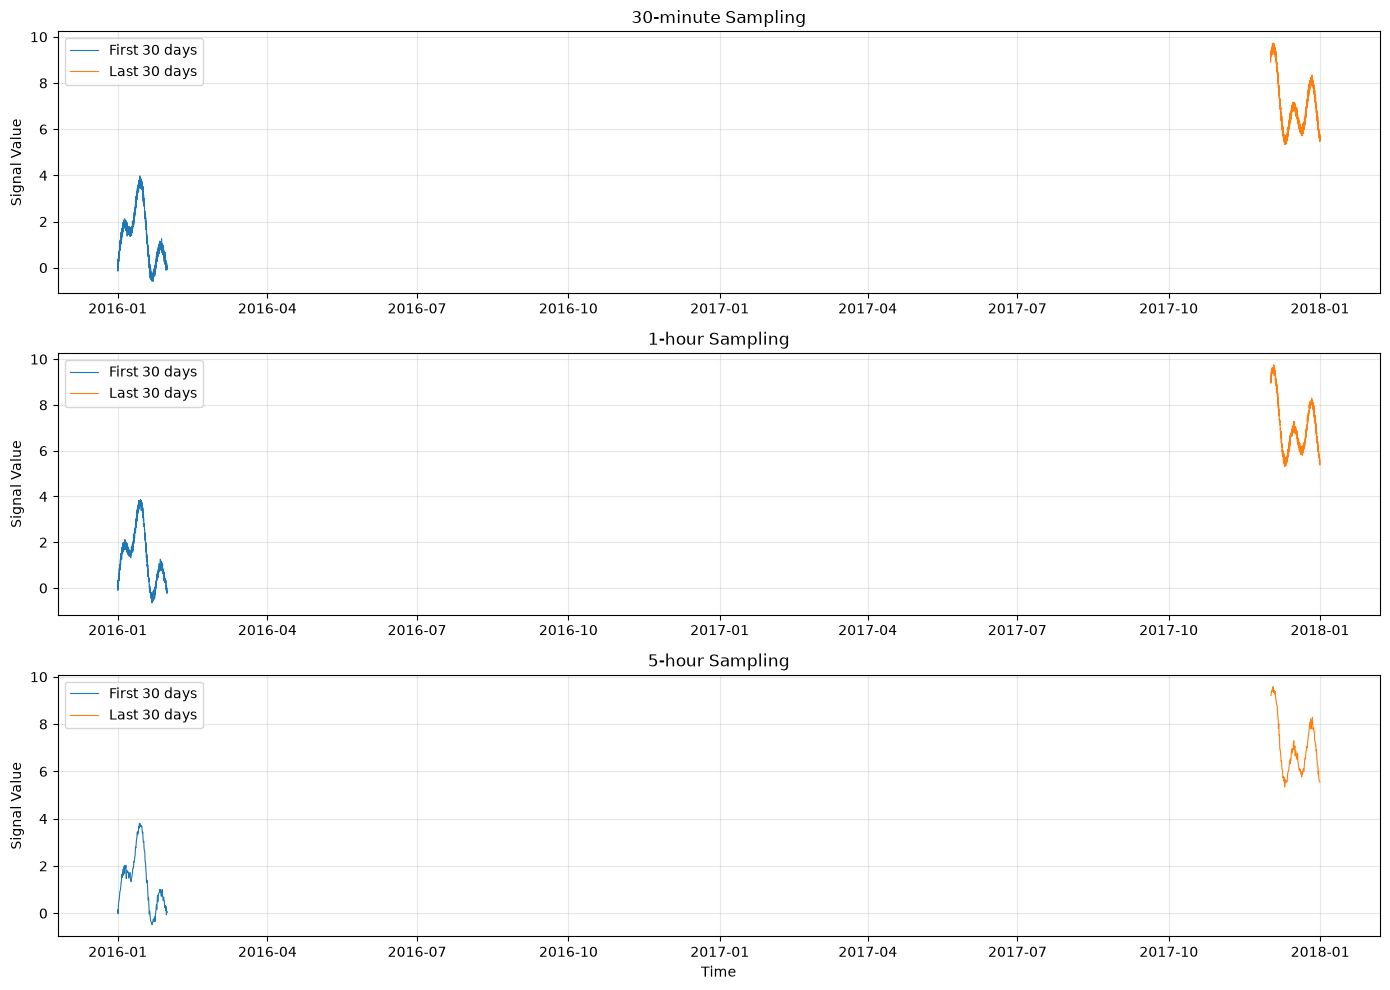

In [19]:
# Inspect the temporal structure at a more detailed scale.
# We use the same 30-day windows for all three datasets so that
# their behavior can be compared directly.

start_date = pd.Timestamp("2016-01-01")
end_date = start_date + pd.Timedelta(days=30)

late_end = data["1-hour"]["datetime"].max()
late_start = late_end - pd.Timedelta(days=30)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (name, df) in zip(axes, data.items()):
    early = df[(df["datetime"] >= start_date) & (df["datetime"] <= end_date)]
    late = df[(df["datetime"] >= late_start) & (df["datetime"] <= late_end)]

    ax.plot(
        early["datetime"],
        early["value"],
        label="First 30 days",
        linewidth=0.8
    )
    ax.plot(
        late["datetime"],
        late["value"],
        label="Last 30 days",
        linewidth=0.8
    )

    ax.set_title(f"{name} Sampling")
    ax.set_ylabel("Signal Value")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Short-Term Temporal Structure

To examine the repeating behavior in more detail, the first and last 30 days of each dataset were compared.

Both periods show clear oscillatory behavior, and similar patterns are visible across the three sampling frequencies. This suggests that the recurring component is present throughout the time series rather than being restricted to a particular part of the dataset.

The signal level in the last 30 days is substantially higher than in the first 30 days, which is consistent with the upward trend observed in the full-series plot.

The short-term oscillations appear to be broadly preserved across the three sampling frequencies, although the 30-minute data provides finer temporal detail.

These visual observations suggest that the signal may contain a combination of:

- a slow-varying trend, and
- one or more recurring components.

However, the exact period cannot be reliably determined from visual inspection. The next step is therefore to remove the slow variation for periodicity diagnostics and use autocorrelation and spectral analysis to identify dominant repeating frequencies from the data itself.

basically I am going to use quantitative validation here

## Detrending and Autocorrelation Analysis

The signal contains a clear slow-varying upward trend in addition to shorter-term recurring fluctuations. A strong trend can produce high autocorrelation at many nearby lags and make it difficult to identify the periodic component.

For periodicity diagnostics, the slow variation is therefore removed using a **7-day centered rolling mean**:

\[
x_t^{detrended} = x_t - \text{RollingMean}_{7D}(x_t)
\]

The 7-day window is used as a smoothing window to separate slow variation from faster repeating fluctuations. It is **not an assumption that the signal has a 7-day period**.

After detrending, we calculate the **autocorrelation function (ACF)** over a sufficiently broad range of lags. Autocorrelation measures how similar the signal is to itself after a given time shift. Repeated peaks in the ACF can indicate recurring periodic structure.

Because the datasets have different sampling frequencies, lags are converted from observations into **hours** before comparison. This allows the same physical time scale to be compared across all three datasets.

The analysis will initially examine lags up to 14 days. This provides enough range to detect recurring patterns without making an assumption about whether the dominant period is daily, weekly, or another timescale.

In [21]:
# Remove slow variation using a centered 7-day rolling mean
detrended_series = {}
acf_results = {}

MAX_LAG_HOURS = 14 * 24

for name, df in data.items():
    temp = df.set_index("datetime")["value"]

    # 7-day centered rolling mean
    rolling_mean = temp.rolling("7D", center=True).mean()

    # Remove slow variation
    detrended = temp - rolling_mean
    detrended_series[name] = detrended

    # Number of observations corresponding to 14 days
    sample_hours = SAMPLE_HOURS[name]
    max_lag = int(MAX_LAG_HOURS / sample_hours)

    # Remove NaN values created at the edges by centered rolling
    values = detrended.dropna().values

    acf = autocorrelation(values, max_lag)

    lags = np.arange(max_lag + 1)
    lag_hours = lags * sample_hours

    acf_results[name] = pd.DataFrame({
        "lag_hours": lag_hours,
        "autocorrelation": acf
    })

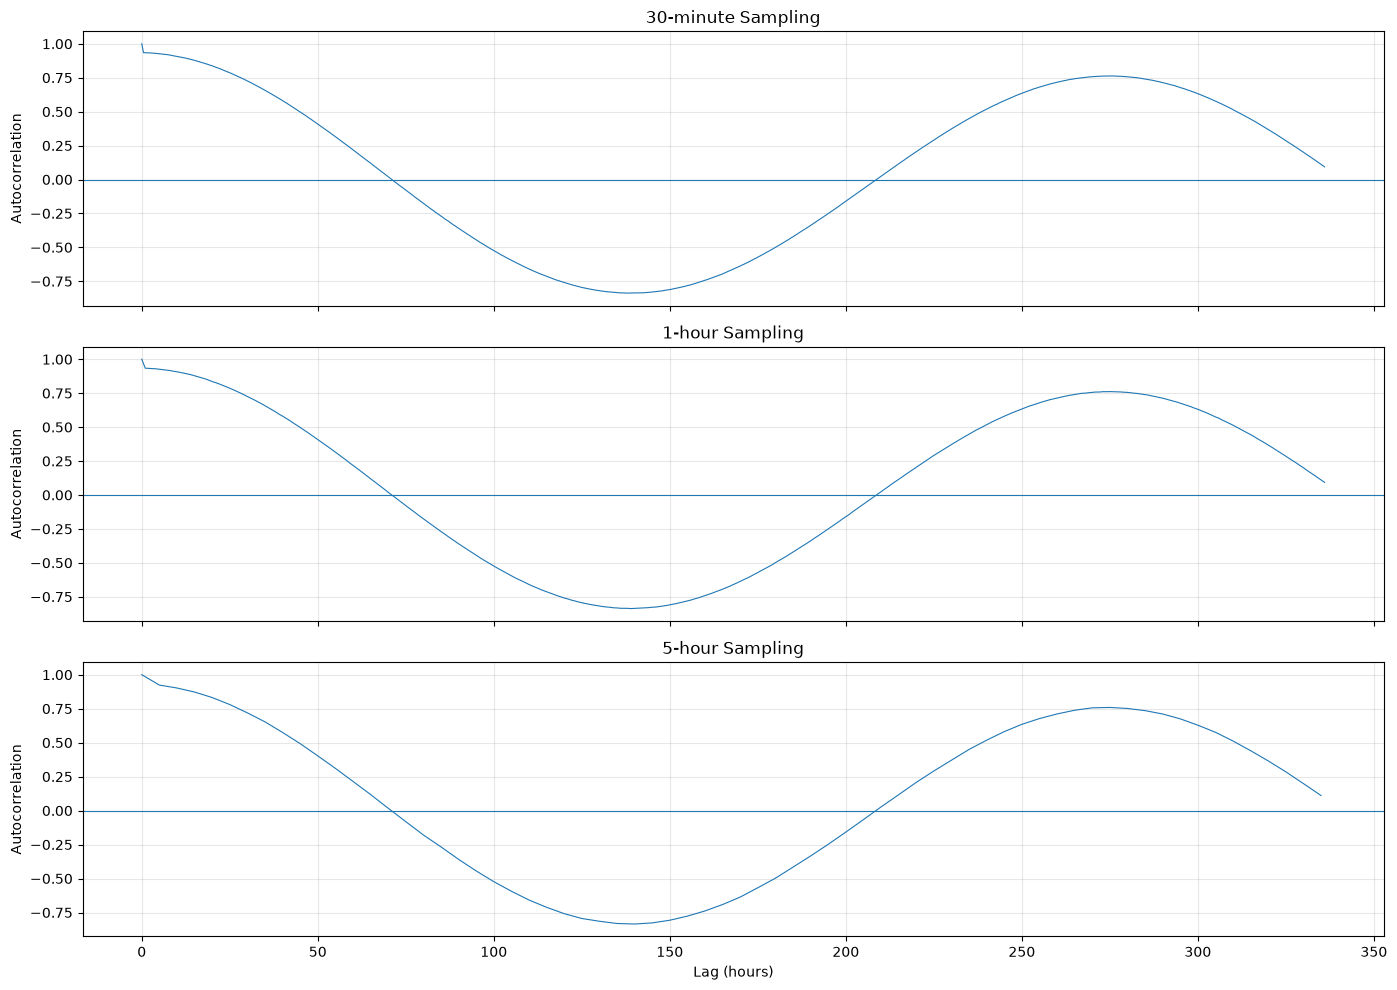

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (name, acf_df) in zip(axes, acf_results.items()):
    ax.plot(
        acf_df["lag_hours"],
        acf_df["autocorrelation"],
        linewidth=0.8
    )

    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"{name} Sampling")
    ax.set_ylabel("Autocorrelation")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Lag (hours)")

plt.tight_layout()
plt.show()

## Autocorrelation Results

The detrended signals show a highly similar autocorrelation structure across all three sampling frequencies.

The ACF decreases from a strong positive value at short lags to a pronounced negative minimum around 135–140 hours, and then increases again to a strong positive maximum around 270–280 hours.

For an approximately periodic signal, the first negative ACF minimum is expected near half of the dominant period, while the following positive maximum is expected near one full period. This gives an initial estimate of approximately:

\[
T \approx 270\text{--}280\text{ hours}
\]

or roughly **11–12 days**.

Importantly, this is treated as a candidate periodicity rather than a final conclusion. The 7-day rolling detrending used for this diagnostic can influence low-frequency components. Therefore, the periodicity will be independently validated using spectral analysis.

The strong similarity of the ACF curves across the three datasets also indicates that the different sampling frequencies preserve the dominant temporal structure of the signal.

## Spectral Analysis

We now use the Fast Fourier Transform (FFT) to independently identify dominant periodicities in the detrended signal.

The FFT decomposes the signal into different frequencies and measures how much signal variation is associated with each frequency. We convert frequency into period:

\[
\text{Period} = \frac{1}{\text{Frequency}}
\]

The sampling interval `d=SAMPLE_HOURS[name]` is provided to `np.fft.rfftfreq()` so that the resulting frequencies are expressed in cycles per hour. This is important because the three datasets have different sampling frequencies.

The zero-frequency component is removed because it represents the mean/DC component rather than a repeating cycle.

For visualization, we focus on periods from **24 hours to 14 days**. This is a diagnostic range chosen around the approximately 11–12 day periodicity suggested by the ACF; it is not an assumption that the signal has a daily or 14-day period.

The resulting power spectrum will be used to identify whether there is a strong spectral peak near the periodicity suggested by the ACF.

In [23]:
# Spectral analysis of the detrended signals

spectral_results = {}

for name, detrended in detrended_series.items():

    values = detrended.dropna().values
    n = len(values)

    # Frequencies corresponding to the FFT components
    frequencies = np.fft.rfftfreq(
        n,
        d=SAMPLE_HOURS[name]
    )

    # FFT and power spectrum
    fft_values = np.fft.rfft(values)
    power = np.abs(fft_values) ** 2

    # Ignore the zero-frequency component
    frequencies = frequencies[1:]
    power = power[1:]

    # Convert frequency to period in hours
    periods_hours = 1 / frequencies

    spectral_results[name] = pd.DataFrame({
        "period_hours": periods_hours,
        "power": power
    })

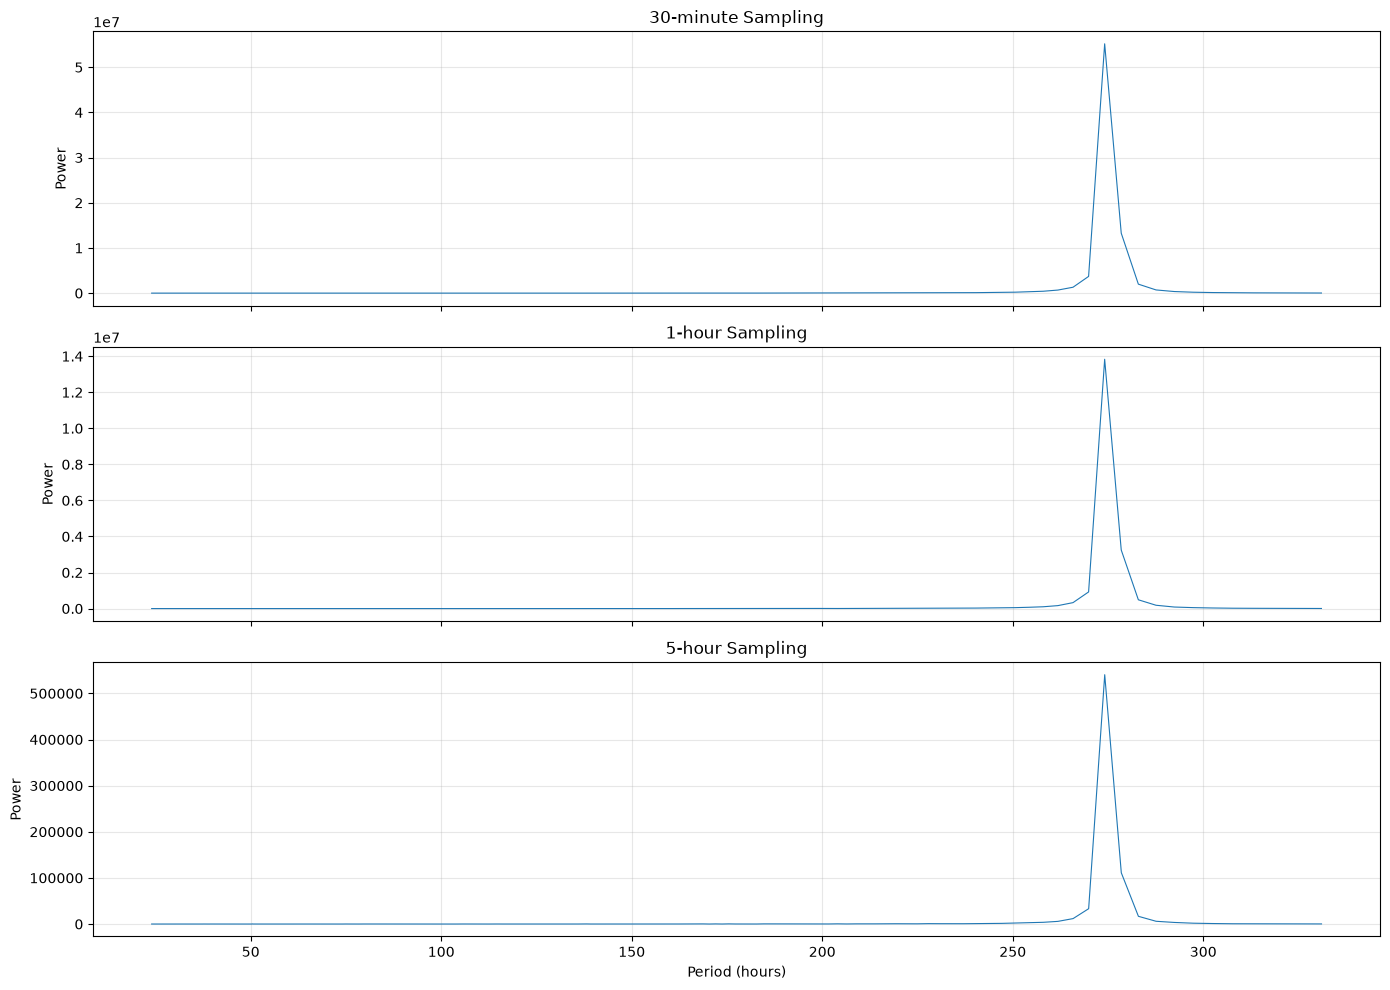

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (name, spectrum) in zip(axes, spectral_results.items()):

    # Focus on periods between 1 and 14 days
    mask = (
        (spectrum["period_hours"] >= 24) &
        (spectrum["period_hours"] <= 14 * 24)
    )

    ax.plot(
        spectrum.loc[mask, "period_hours"],
        spectrum.loc[mask, "power"],
        linewidth=0.8
    )

    ax.set_title(f"{name} Sampling")
    ax.set_ylabel("Power")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Period (hours)")

plt.tight_layout()
plt.show()

## Spectral Analysis Results

The power spectra show a pronounced dominant peak for all three datasets at approximately 270–280 hours, corresponding to roughly 11–12 days.

This independently confirms the periodicity suggested by the autocorrelation analysis. The agreement between the two methods provides stronger evidence that the signal contains a dominant recurring component with a period of approximately 11–12 days.

The dominant peak occurs at a similar period across all three sampling frequencies, indicating that the underlying periodic structure is preserved even after downsampling.

The absolute power values are not directly compared across datasets because the datasets contain different numbers of observations. For dataset selection, the important evidence is the consistency of the dominant frequency/period and how well each sampling frequency resolves that periodic structure.

## Quantifying the Dominant Period

The spectral plot shows a clear dominant peak around 270–280 hours. We now extract the exact peak period for each dataset and convert it into days.

We also calculate the number of observations available within one dominant cycle. This helps us compare how well each sampling frequency resolves the recurring pattern.

In [25]:
dominant_periods = []

for name, spectrum in spectral_results.items():

    peak_idx = spectrum["power"].idxmax()

    peak_period_hours = spectrum.loc[peak_idx, "period_hours"]
    observations_per_cycle = peak_period_hours / SAMPLE_HOURS[name]

    dominant_periods.append({
        "Dataset": name,
        "Dominant period (hours)": peak_period_hours,
        "Dominant period (days)": peak_period_hours / 24,
        "Observations per cycle": observations_per_cycle
    })

dominant_period_summary = (
    pd.DataFrame(dominant_periods)
    .set_index("Dataset")
    .round(2)
)

dominant_period_summary

,Dominant period (hours),Dominant period (days),Observations per cycle
Dataset,,,
30-minute,274.12,11.42,548.25
1-hour,274.12,11.42,274.12
5-hour,274.14,11.42,54.83


## Dominant Period Across Sampling Frequencies

The spectral analysis identifies a dominant period of approximately **274 hours (11.42 days)** for all three datasets.

The periodicity is therefore consistent across sampling frequencies, suggesting that it represents an underlying characteristic of the signal.

The number of observations per dominant cycle varies from approximately 548 observations for the 30-minute data to 55 observations for the 5-hour data. Thus, even the 5-hour dataset provides substantial resolution of the dominant periodic cycle.

The remaining dataset-selection question is whether the higher-frequency datasets contain meaningful additional temporal information beyond this dominant recurring structure.

## Comparing Information Across Sampling Frequencies

The dominant periodicity is preserved across all three datasets, but the higher-frequency datasets may contain additional short-term information.

To assess this, we compare the higher-frequency signals after aggregating them to the 5-hour frequency. If the aggregated signals closely match the original 5-hour observations, then the finer sampling may provide limited additional information for forecasting the dominant structure.

In [27]:
# Aggregate the higher-frequency datasets to 5-hour intervals
# using the mean signal value within each 5-hour window.

data_30m_5h = (
    data["30-minute"]
    .set_index("datetime")["value"]
    .resample("5h")
    .mean()
)

data_1h_5h = (
    data["1-hour"]
    .set_index("datetime")["value"]
    .resample("5h")
    .mean()
)

data_5h = (
    data["5-hour"]
    .set_index("datetime")["value"]
)

# Align all three series on their common timestamps
comparison = pd.concat(
    [
        data_30m_5h.rename("30-minute → 5-hour"),
        data_1h_5h.rename("1-hour → 5-hour"),
        data_5h.rename("Original 5-hour")
    ],
    axis=1
).dropna()

comparison.head()

,30-minute → 5-hour,1-hour → 5-hour,Original 5-hour
datetime,,,
2016-01-01 00:00:00,0.106537,0.074380,0.140965
2016-01-01 05:00:00,0.189791,0.222205,-0.014609
2016-01-01 10:00:00,0.379657,0.405170,0.325199
2016-01-01 15:00:00,0.520311,0.495214,0.504311
2016-01-01 20:00:00,0.622269,0.615287,0.545418


## Quantifying Information Loss from Downsampling

The aggregated higher-frequency signals are compared with the original 5-hour observations using MAE and RMSE.

These metrics quantify how much the 5-hour representation differs from the information available at higher sampling frequencies.

Smaller errors indicate that the 5-hour sampling preserves the signal reasonably well at this scale.

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

comparison_metrics = []

for column in ["30-minute → 5-hour", "1-hour → 5-hour"]:
    actual = comparison["Original 5-hour"]
    aggregated = comparison[column]

    comparison_metrics.append({
        "Comparison": column,
        "MAE": mean_absolute_error(actual, aggregated),
        "RMSE": np.sqrt(mean_squared_error(actual, aggregated))
    })

pd.DataFrame(comparison_metrics).round(4)

,Comparison,MAE,RMSE
0,30-minute → 5-hour,0.0869,0.1087
1,1-hour → 5-hour,0.0895,0.1127


## Downsampling Comparison Results

The aggregated 30-minute and 1-hour signals differ only slightly from the original 5-hour observations.

The 30-minute to 5-hour comparison gives an MAE of 0.0869 and RMSE of 0.1087, while the 1-hour to 5-hour comparison gives an MAE of 0.0895 and RMSE of 0.1127. These errors are small relative to the signal standard deviation of approximately 2.15.

This suggests that the main temporal structure of the signal is largely preserved at 5-hour resolution. However, error metrics alone are not sufficient to determine whether higher-frequency observations contain useful additional information, so the relationship between the series will be examined visually and through correlation.

At the 5-hour scale, the higher-frequency data doesn't appear dramatically different from the original 5-hour signal.

In [29]:
# Inspect the first 5-hour interval in the high-frequency data

start = pd.Timestamp("2016-01-01 00:00")
end = pd.Timestamp("2016-01-01 05:00")

for name in ["30-minute", "1-hour"]:
    subset = data[name][
        (data[name]["datetime"] >= start) &
        (data[name]["datetime"] < end)
    ]

    print(f"\n{name}")
    display(subset)
    print("Mean:", subset["value"].mean())

print("\nOriginal 5-hour observation:")
display(
    data["5-hour"][
        data["5-hour"]["datetime"] == start
    ]
)


30-minute


,datetime,value
0,2016-01-01 00:00:00,0.022925
1,2016-01-01 00:30:00,0.051618
2,2016-01-01 01:00:00,0.113476
3,2016-01-01 01:30:00,0.123141
4,2016-01-01 02:00:00,0.135766
5,2016-01-01 02:30:00,0.108779
6,2016-01-01 03:00:00,-0.144573
7,2016-01-01 03:30:00,0.133084
8,2016-01-01 04:00:00,0.359012
9,2016-01-01 04:30:00,0.162139


Mean: 0.10653672452737484

1-hour


,datetime,value
0,2016-01-01 00:00:00,-0.101431
1,2016-01-01 01:00:00,0.139217
2,2016-01-01 02:00:00,0.059007
3,2016-01-01 03:00:00,0.337537
4,2016-01-01 04:00:00,-0.062431


Mean: 0.07437982941402556

Original 5-hour observation:


,datetime,value
0,2016-01-01,0.140965


## Comparison at Common Timestamps

The previous aggregation analysis showed that the higher-frequency signals are broadly consistent with the 5-hour series, but the original 5-hour values are not themselves interval averages.

To make a direct comparison, we therefore examine observations at timestamps shared by all three datasets. This allows us to assess how consistently the different sampling frequencies represent the same underlying signal without introducing an additional aggregation step.

In [30]:
# Keep only timestamps that are present in all three datasets.

common = data["30-minute"].set_index("datetime")["value"].rename("30-minute").to_frame()

common = common.join(
    data["1-hour"].set_index("datetime")["value"].rename("1-hour"),
    how="inner"
)

common = common.join(
    data["5-hour"].set_index("datetime")["value"].rename("5-hour"),
    how="inner"
)

common.head()

,30-minute,1-hour,5-hour
datetime,,,
2016-01-01 00:00:00,0.022925,-0.101431,0.140965
2016-01-01 05:00:00,0.182189,0.128667,-0.014609
2016-01-01 10:00:00,0.227104,0.348162,0.325199
2016-01-01 15:00:00,0.366530,0.605384,0.504311
2016-01-01 20:00:00,0.553495,0.648842,0.545418


## Agreement at Common Timestamps

The common-timestamp dataset allows a direct comparison of the three sampling frequencies without introducing aggregation.

We now measure the pairwise Pearson correlation between the series. High correlation indicates that the datasets preserve similar temporal movements at the timestamps they share.

In [31]:
correlation_matrix = common.corr()

correlation_matrix.round(4)

,30-minute,1-hour,5-hour
30-minute,1.0000,0.9980,0.9977
1-hour,0.9980,1.0000,0.9977
5-hour,0.9977,0.9977,1.0000


## Short-Term Variability

To assess whether the higher-frequency datasets contain meaningful additional short-term information, we examine the first differences of each signal:

\[
\Delta y_t = y_t - y_{t-1}
\]

The standard deviation of these differences measures the typical magnitude of changes between consecutive observations at each sampling frequency.

Larger values indicate greater short-term variability at that sampling resolution. This helps distinguish the dominant long-term periodic structure from finer-scale fluctuations.

In [32]:
difference_stats = []

for name, df in data.items():

    differences = df["value"].diff().dropna()

    difference_stats.append({
        "Dataset": name,
        "Mean absolute change": differences.abs().mean(),
        "Std of change": differences.std(),
        "Max absolute change": differences.abs().max()
    })

difference_summary = (
    pd.DataFrame(difference_stats)
    .set_index("Dataset")
    .round(4)
)

difference_summary

,Mean absolute change,Std of change,Max absolute change
Dataset,,,
30-minute,0.1125,0.1411,0.5746
1-hour,0.1130,0.1419,0.5571
5-hour,0.1334,0.1682,0.6230


## Within-Window Short-Term Variability

Raw first differences are not directly comparable across the three datasets because the sampling intervals differ.

Instead, we measure the variability within each 5-hour window of the higher-frequency datasets. This quantifies how much signal variation occurs below the 5-hour sampling scale and therefore indicates how much short-term information would be lost when using the 5-hour dataset.

In [33]:
within_window_stats = []

for name in ["30-minute", "1-hour"]:

    series = data[name].set_index("datetime")["value"]

    # Standard deviation of observations within each 5-hour window
    window_std = series.resample("5h").std().dropna()

    within_window_stats.append({
        "Dataset": name,
        "Mean within-5h std": window_std.mean(),
        "Median within-5h std": window_std.median(),
        "95th percentile": window_std.quantile(0.95)
    })

within_window_summary = (
    pd.DataFrame(within_window_stats)
    .set_index("Dataset")
    .round(4)
)

within_window_summary

,Mean within-5h std,Median within-5h std,95th percentile
Dataset,,,
30-minute,0.1005,0.0989,0.1414
1-hour,0.0972,0.0944,0.1602


# 30-minute and 1-hour are very similar

Their mean within-window variability is:

30-minute → 0.1005
1-hour    → 0.0972

That's extremely close.

So there isn't evidence here that the 30-minute dataset contains substantially more useful short-term structure than the 1-hour dataset.

## Within-Window Variability Results

The typical variation within a 5-hour window is approximately 0.10 for both the 30-minute and 1-hour datasets, which is small relative to the overall signal standard deviation of approximately 2.15.

The two higher-frequency datasets also show very similar within-window variability, suggesting that the 30-minute sampling does not provide substantially more short-term variation than the 1-hour sampling at this scale.

This indicates that most of the important signal variation occurs at timescales larger than 5 hours. However, this analysis measures variability rather than noise, so it is not used alone to discard the higher-frequency information.

## Short-Term Resolution Comparison

We now inspect a short two-day period to visually compare the temporal detail captured by the three sampling frequencies.

This helps determine whether the additional observations in the 30-minute and 1-hour datasets reveal meaningful short-term structure that is not represented by the 5-hour dataset.

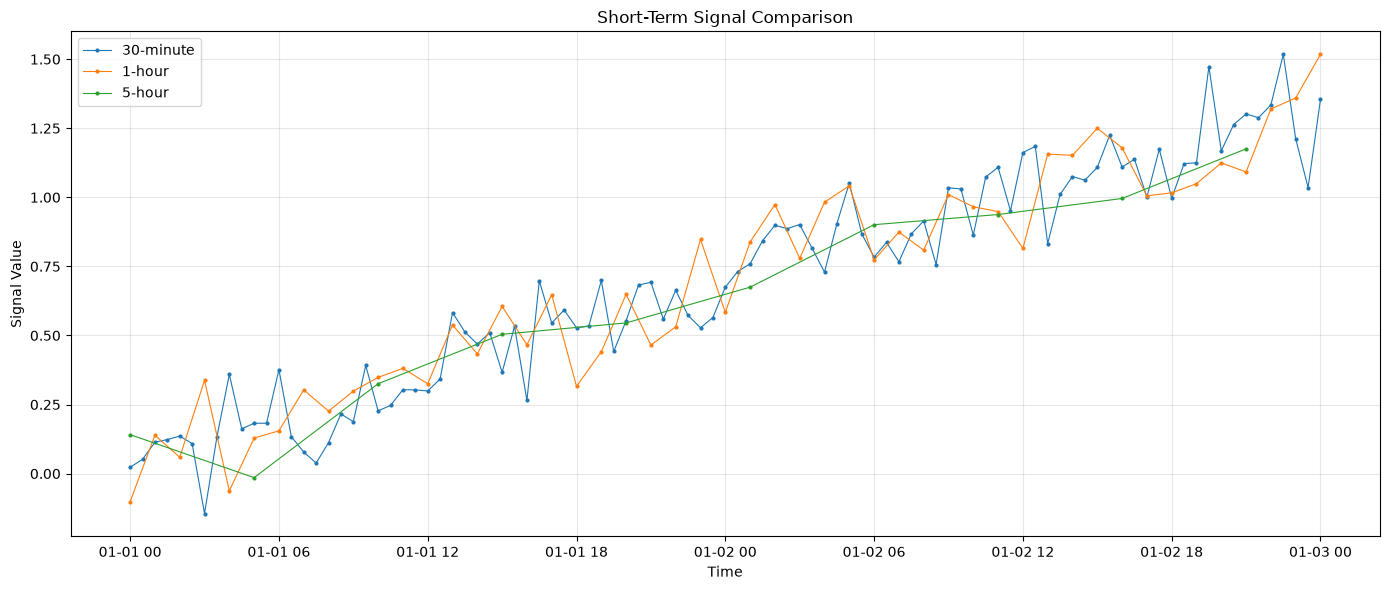

In [34]:
# Compare the three sampling frequencies over a short 2-day window

start = pd.Timestamp("2016-01-01")
end = start + pd.Timedelta(days=2)

fig, ax = plt.subplots(figsize=(14, 6))

for name, df in data.items():
    subset = df[
        (df["datetime"] >= start) &
        (df["datetime"] <= end)
    ]

    ax.plot(
        subset["datetime"],
        subset["value"],
        marker="o",
        markersize=2,
        linewidth=0.8,
        label=name
    )

ax.set_title("Short-Term Signal Comparison")
ax.set_xlabel("Time")
ax.set_ylabel("Signal Value")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Short-Term Resolution Comparison

The short-term comparison shows that all three sampling frequencies follow the same underlying trajectory. The 30-minute and 1-hour datasets contain additional short-term fluctuations, while the 5-hour dataset provides a smoother representation of the signal.

Combined with the high correlation between the datasets and the consistent dominant periodicity, this suggests that the finer sampling frequencies provide limited additional information for modeling the main recurring structure.

### Dataset Selection

The **5-hour dataset is selected** for subsequent forecasting experiments.

The selection is based on the following evidence:

- The data is complete and regularly sampled.
- All three datasets exhibit the same dominant period of approximately **274 hours (11.42 days)**.
- The 5-hour dataset provides approximately **55 observations per dominant cycle**, giving sufficient temporal resolution.
- The datasets have very high agreement at common timestamps, with pairwise correlations of approximately **0.998**.
- The higher-frequency datasets primarily provide additional short-term fluctuations, while the major temporal structure is preserved at 5-hour resolution.

Therefore, the 5-hour dataset provides a suitable balance between preserving the relevant temporal structure and avoiding unnecessary high-frequency variability.